# Crowd Counting via Density Maps — Colab-Optimized Starter Notebook

This notebook is designed for a **course project** rather than paper-level reproduction.
It is optimized for **free Colab / modest GPU access** by using:
- a **frozen pretrained frontend**,
- **short training runs**,
- **random crops** instead of full-resolution training,
- a simplified CSRNet-style backend.

## Student coding tasks
You are responsible for these three coding parts:
1. `make_density_map`
2. `evaluate_model`
3. run a small `sigma` study by changing the provided `SIGMA` parameter and rerunning the notebook cells

Visualization code is already provided so you do not need to debug plotting.

### AI Disclosure
This notebook was drafted by ChatGPT 5.4 Thinking and then reviewed and edited by Breschine Cummins for use in this course.

In [154]:
# Uncomment in Colab if needed.
# !pip -q install scipy matplotlib pillow

In [155]:
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from scipy.ndimage import gaussian_filter
from scipy.io import loadmat

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from tqdm import tqdm

SEED = 508
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


## Configuration

Update the dataset path to wherever you placed ShanghaiTech Part A in Colab or Drive.

In [156]:
DATA_ROOT = Path("C:\\Users\\mrsig\\Desktop\\M508\\project4\\part_A_final")   # change this

TRAIN_IMAGES = DATA_ROOT / "train_data" / "images"
TRAIN_GT     = DATA_ROOT / "train_data" / "ground_truth"
TEST_IMAGES  = DATA_ROOT / "test_data" / "images"
TEST_GT      = DATA_ROOT / "test_data" / "ground_truth"

IMG_EXT = ".jpg"

BATCH_SIZE = 2
NUM_EPOCHS = 5
LR = 0.000248240415225025
WEIGHT_DECAY = 0.00017032992018687848
INPUT_SIZE = 384
USE_RANDOM_CROPS = True
FREEZE_FRONTEND = True
NUM_WORKERS = 0

SIGMA = 5

## Annotation helpers

The official ShanghaiTech annotations are stored in `.mat` files.
This helper is already provided so you do not need to debug file parsing.

In [157]:
def load_image(path):
    return Image.open(path).convert("RGB")

def get_gt_points_from_mat(mat_path):
    data = loadmat(mat_path)
    points = data["image_info"][0,0][0,0][0]
    return np.asarray(points, dtype=np.float32)

## TODO 1: Density map generation

Write a function that:
- creates an `H x W` array of zeros,
- places an impulse of size `1` at each annotated point,
- applies a Gaussian filter with standard deviation `sigma`,
- returns the density map as a NumPy array of type `float32`.

The sum of the density map should be close to the annotated count.

In [158]:
def make_density_map(points, image_size, sigma):
    '''
    Inputs
    ------
    points: array of shape (n, 2), with entries (x, y)
    image_size: tuple (H, W)
    sigma: Gaussian bandwidth

    Output
    ------
    density: NumPy array of shape (H, W), dtype float32
    '''
    H, W = image_size
    density = np.zeros((H, W), dtype=np.float32)

    for x, y in points:
        xi = int(round(x))
        yi = int(round(y))
        if 0 <= xi < W and 0 <= yi < H:
            density[yi, xi] += 1.0

    density = gaussian_filter(density, sigma=sigma, mode="constant")
    return density.astype(np.float32)



## Quick density-map check

In [ ]:
def density_map_sanity_check(image_path, gt_path, sigma):
    image = load_image(image_path)
    points = get_gt_points_from_mat(gt_path)
    density = make_density_map(points, (image.height, image.width), sigma=sigma)

    print("Image:", image_path.name)
    print("Annotated count:", len(points))
    print("Density-map sum:", float(density.sum()))

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(image)
    axes[0].set_title("Image")
    axes[0].axis("off")

    im = axes[1].imshow(density, cmap="jet")
    axes[1].set_title(f"Density map\nSum = {density.sum():.2f}")
    axes[1].axis("off")
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

sample_img = sorted(TRAIN_IMAGES.glob(f"*{IMG_EXT}"))[0]
sample_gt = TRAIN_GT / sample_img.name.replace("IMG_", "GT_IMG_").replace(".jpg", ".mat")
density_map_sanity_check(sample_img, sample_gt, sigma=100000)

## Dataset and data loaders

This infrastructure is provided so the project stays focused on density maps,
evaluation, and interpretation rather than data-pipeline debugging.

In [160]:
class CrowdDataset(Dataset):
    def __init__(self, image_dir, gt_dir, sigma=15.0, transform=None,
                 use_random_crops=False, crop_size=384):
        self.image_paths = sorted(image_dir.glob(f"*{IMG_EXT}"))
        self.gt_dir = gt_dir
        self.sigma = sigma
        self.transform = transform
        self.use_random_crops = use_random_crops
        self.crop_size = crop_size

    def __len__(self):
        return len(self.image_paths)

    def _gt_path(self, image_path):
        return self.gt_dir / image_path.name.replace("IMG_", "GT_IMG_").replace(".jpg", ".mat")

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        gt_path = self._gt_path(image_path)

        image = load_image(image_path)
        points = get_gt_points_from_mat(gt_path)

        W, H = image.size

        if self.use_random_crops:
            crop_h = min(self.crop_size, H)
            crop_w = min(self.crop_size, W)
            top = 0 if H == crop_h else np.random.randint(0, H - crop_h + 1)
            left = 0 if W == crop_w else np.random.randint(0, W - crop_w + 1)

            image = image.crop((left, top, left + crop_w, top + crop_h))

            if len(points) > 0:
                mask = (
                    (points[:, 0] >= left) & (points[:, 0] < left + crop_w) &
                    (points[:, 1] >= top)  & (points[:, 1] < top + crop_h)
                )
                points = points[mask].copy()
                points[:, 0] -= left
                points[:, 1] -= top

            pad_h = self.crop_size - crop_h
            pad_w = self.crop_size - crop_w
            if pad_h > 0 or pad_w > 0:
                image_np = np.array(image)
                image_np = np.pad(
                    image_np,
                    ((0, pad_h), (0, pad_w), (0, 0)),
                    mode="constant",
                    constant_values=0,
                )
                image = Image.fromarray(image_np)

            H, W = self.crop_size, self.crop_size
        else:
            H, W = image.height, image.width

        density = make_density_map(points, image_size=(H, W), sigma=self.sigma)

        if self.transform is not None:
            image_tensor = self.transform(image)
        else:
            image_tensor = transforms.ToTensor()(image)

        density_tensor = torch.from_numpy(density).unsqueeze(0)
        count = torch.tensor(float(len(points)), dtype=torch.float32)

        return image_tensor, density_tensor, count, str(image_path)

image_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_ds = CrowdDataset(
    TRAIN_IMAGES, TRAIN_GT,
    sigma=SIGMA,
    transform=image_transform,
    use_random_crops=USE_RANDOM_CROPS,
    crop_size=INPUT_SIZE
)
test_ds = CrowdDataset(
    TEST_IMAGES, TEST_GT,
    sigma=SIGMA,
    transform=image_transform,
    use_random_crops=False
)

train_batch_size = BATCH_SIZE if USE_RANDOM_CROPS else 1
train_loader = DataLoader(train_ds, batch_size=train_batch_size, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

print("Train size:", len(train_ds))
print("Test size:", len(test_ds))


Train size: 300
Test size: 182


## Simplified CSRNet-style model

This version uses:
- VGG16 frontend through `pool3`,
- frozen pretrained weights by default,
- six dilated `3 x 3` backend layers with dilation rate `2`,
- a final `1 x 1` output layer.

In [161]:
class CrowdCounter(nn.Module):
    def __init__(self, freeze_frontend=True):
        super().__init__()

        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        self.frontend = nn.Sequential(*list(vgg.features.children())[:17])

        if freeze_frontend:
            for p in self.frontend.parameters():
                p.requires_grad = False

        dilation = 2
        channels = 64

        backend = []
        backend.append(nn.Conv2d(256, channels, kernel_size=3, padding=dilation, dilation=dilation))
        backend.append(nn.ReLU(inplace=True))
        for _ in range(5):
            backend.append(nn.Conv2d(channels, channels, kernel_size=3, padding=dilation, dilation=dilation))
            backend.append(nn.ReLU(inplace=True))

        self.backend = nn.Sequential(*backend)
        self.final = nn.Conv2d(channels, 1, kernel_size=1)

    def forward(self, x):
        H, W = x.shape[-2:]
        z = self.frontend(x)
        z = self.backend(z)
        z = self.final(z)
        z = F.interpolate(z, size=(H, W), mode="bilinear", align_corners=False)
        return z

model = CrowdCounter(freeze_frontend=FREEZE_FRONTEND).to(DEVICE)

print("Trainable parameters:",
      sum(p.numel() for p in model.parameters() if p.requires_grad))

Trainable parameters: 332225


In [162]:
criterion = nn.MSELoss(reduction="sum")
optimizer = torch.optim.Adam(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

In [163]:
def train_one_epoch(model, loader, optimizer, criterion, device=DEVICE):
    model.train()
    total_loss = 0.0

    for images, density_gt, counts_gt, paths in loader:
        images = images.to(device)
        density_gt = density_gt.to(device)

        optimizer.zero_grad()
        density_pred = model(images)
        loss = criterion(density_pred, density_gt) / images.size(0)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / max(1, len(loader))

## TODO 2: Evaluation metrics

Implement:
- predicted count = sum of the predicted density map,
- MAE,
- RMSE.

In [164]:
@torch.no_grad()
def evaluate_model(model, loader, device=DEVICE):
    model.eval()

    abs_errors = []
    sq_errors = []

    for images, density_gt, counts_gt, paths in loader:
        images = images.to(device)
        density_pred = model(images)

        count_pred = float(density_pred.sum().cpu().item())
        count_gt = float(counts_gt.item())

        error = abs(count_gt - count_pred)
        sq_error = error**2
        abs_errors.append(error)
        sq_errors.append(sq_error)

    mae = np.mean(abs_errors)
    rmse = np.sqrt(np.mean(sq_errors))

    return mae, rmse


In [165]:
def fit_model(model, train_loader, test_loader, epochs=4, device=DEVICE):
    history = {"train_loss": [], "mae": [], "rmse": []}

    for epoch in tqdm(range(1, epochs + 1),desc="Epochs"):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device=device)
        mae, rmse = evaluate_model(model, test_loader, device=device)

        history["train_loss"].append(train_loss)
        history["mae"].append(mae)
        history["rmse"].append(rmse)

        print(f"Epoch {epoch:02d} | train loss = {train_loss:.3f} | MAE = {mae:.3f} | RMSE = {rmse:.3f}")

    return history

fit_model(model, train_loader, test_loader, epochs=NUM_EPOCHS, device=DEVICE)


Epochs:  20%|██        | 1/5 [00:13<00:54, 13.54s/it]

Epoch 01 | train loss = 3.492 | MAE = 195.259 | RMSE = 298.793


Epochs:  40%|████      | 2/5 [00:26<00:40, 13.40s/it]

Epoch 02 | train loss = 0.851 | MAE = 496.070 | RMSE = 587.606


Epochs:  60%|██████    | 3/5 [00:40<00:26, 13.44s/it]

Epoch 03 | train loss = 0.781 | MAE = 121.631 | RMSE = 170.599


Epochs:  80%|████████  | 4/5 [00:54<00:13, 13.70s/it]

Epoch 04 | train loss = 0.915 | MAE = 129.382 | RMSE = 189.246


Epochs:  80%|████████  | 4/5 [00:59<00:14, 14.88s/it]


KeyboardInterrupt: 

In [151]:
def plot_history(history):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(6,4))
    plt.plot(epochs, history["train_loss"], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Train loss")
    plt.title("Training loss")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(epochs, history["mae"], marker="o", label="MAE")
    plt.plot(epochs, history["rmse"], marker="o", label="RMSE")
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.title("Test metrics")
    plt.legend()
    plt.grid(True)
    plt.show()

#plot_history(history)

## Visualization/reporting cell


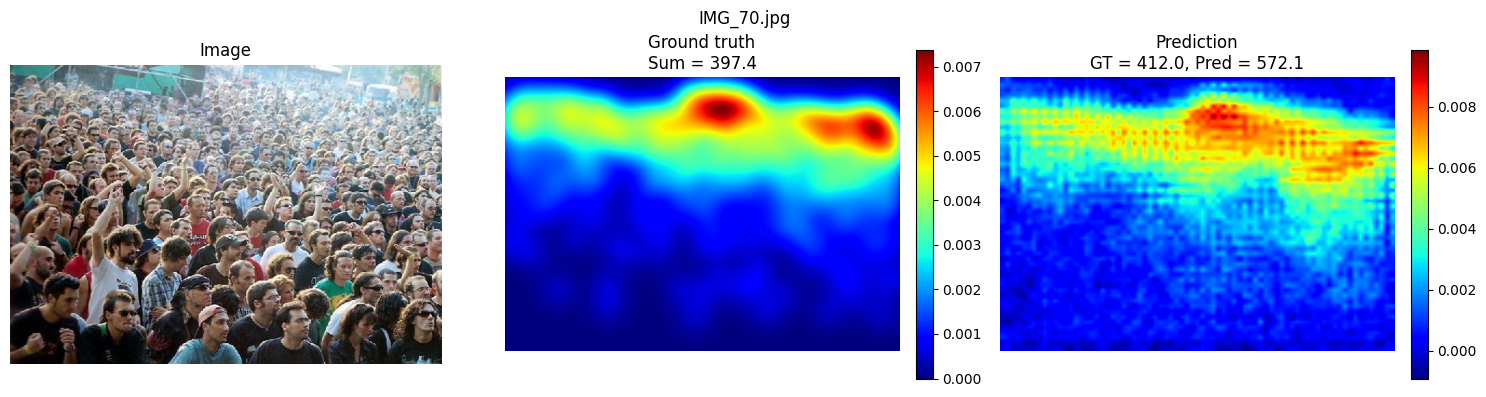

In [152]:
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

@torch.no_grad()
def visualize_prediction(model, dataset, idx, device=DEVICE):
    model.eval()
    image_tensor, density_gt, count_gt, path = dataset[idx]
    pred = model(image_tensor.unsqueeze(0).to(device)).squeeze().cpu().numpy()

    image_np = inv_normalize(image_tensor).clamp(0,1).permute(1,2,0).numpy()
    density_gt_np = density_gt.squeeze().numpy()
    count_pred = float(pred.sum())

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(image_np)
    axes[0].set_title("Image")
    axes[0].axis("off")

    im1 = axes[1].imshow(density_gt_np, cmap="jet")
    axes[1].set_title(f"Ground truth\nSum = {density_gt_np.sum():.1f}")
    axes[1].axis("off")
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    im2 = axes[2].imshow(pred, cmap="jet")
    axes[2].set_title(f"Prediction\nGT = {float(count_gt):.1f}, Pred = {count_pred:.1f}")
    axes[2].axis("off")
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    plt.suptitle(Path(path).name)
    plt.tight_layout()
    plt.show()

# Example:
visualize_prediction(model, test_ds, idx=150)


## TODO 4: Small sigma study

For Colab, it is better to run each `sigma` value **independently**.

So for this part:
- set `SIGMA` near the top of the notebook,
- rerun the dataset-construction and training/evaluation cells,
- record the final MAE and RMSE,
- repeat for your other `sigma` values.

This avoids running a long multi-experiment loop in a single session.


In [153]:
# For the sigma study:
# 1. Change SIGMA near the top of the notebook.
# 2. Re-run the dataset-construction cells.
# 3. Recreate the model.
# 4. Re-run training/evaluation.
#
# Record the final MAE and RMSE for each chosen sigma.


## Suggested deliverables to record in your report

- two density-map sanity checks,
- final MAE and RMSE,
- four prediction examples using the provided visualization function,
- sigma comparison table,
- discussion of successes and failure modes.
